# Formula 1 Data Science Project
## Ensemble Learning Module

Methods covered:
- **Random Forest** (bagging) — primary method
- **AdaBoost** (boosting) — for comparison
- **Voting Classifier** (hard + soft voting combining RF, SVM, LR) — for comparison

Task: Predict `IsSoft` (1=SOFT tyre, 0=MEDIUM/HARD) from 9 F1 lap telemetry features.

---
## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)

import os
os.makedirs('img', exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Generate Overview Diagrams

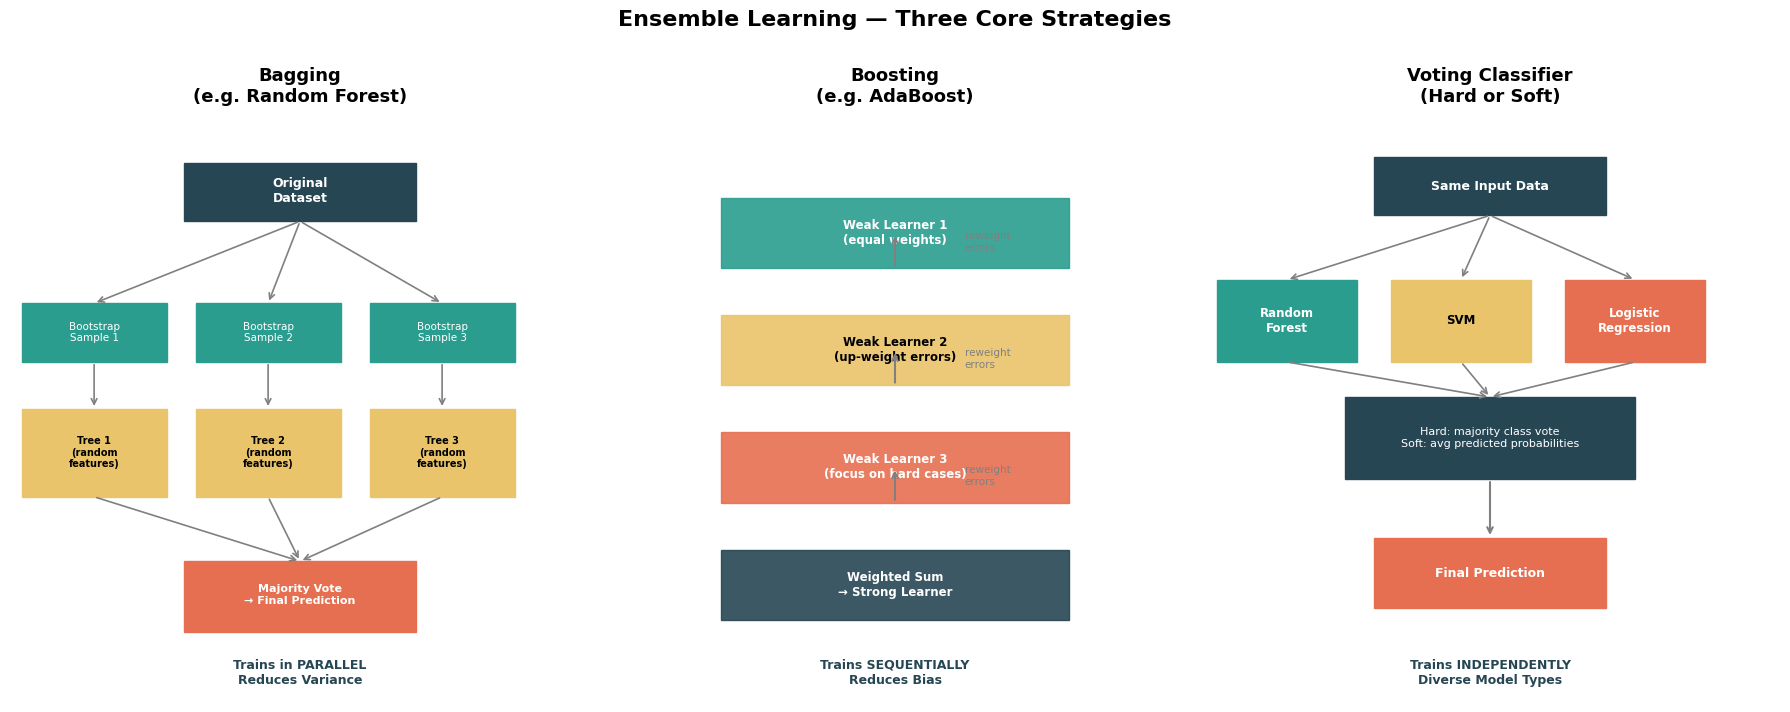

Saved → img/ensemble_overview.png


In [2]:
# ── Ensemble Overview Diagram: Bagging vs Boosting vs Voting ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Ensemble Learning — Three Core Strategies', fontsize=16, fontweight='bold', y=1.01)

for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

# ── BAGGING (Random Forest) ──────────────────────────────
ax = axes[0]
ax.set_title('Bagging\n(e.g. Random Forest)', fontweight='bold', fontsize=13, pad=10)

# Dataset box
ax.add_patch(plt.Rectangle((3, 8.2), 4, 1.0, color='#264653', zorder=3))
ax.text(5, 8.72, 'Original\nDataset', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# Bootstrap samples
for i, (x, label) in enumerate([(1,1),(4,1),(7,1)]):
    ax.add_patch(plt.Rectangle((x-0.8, 5.8), 2.5, 1.0, color='#2a9d8f', zorder=3))
    ax.text(x+0.45, 6.3, f'Bootstrap\nSample {i+1}', ha='center', va='center', color='white', fontsize=7.5)
    ax.annotate('', xy=(x+0.45, 6.8), xytext=(5, 8.2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Trees
for i, x in enumerate([1,4,7]):
    ax.add_patch(plt.Rectangle((x-0.8, 3.5), 2.5, 1.5, color='#e9c46a', zorder=3))
    ax.text(x+0.45, 4.25, f'Tree {i+1}\n(random\nfeatures)', ha='center', va='center', fontsize=7, fontweight='bold')
    ax.annotate('', xy=(x+0.45, 5.0), xytext=(x+0.45, 5.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Majority vote
ax.add_patch(plt.Rectangle((3, 1.2), 4, 1.2, color='#e76f51', zorder=3))
ax.text(5, 1.82, 'Majority Vote\n→ Final Prediction', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
for x in [1,4,7]:
    ax.annotate('', xy=(5, 2.4), xytext=(x+0.45, 3.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.text(5, 0.5, 'Trains in PARALLEL\nReduces Variance', ha='center', va='center',
        fontsize=9, color='#264653', fontweight='bold')

# ── BOOSTING (AdaBoost) ──────────────────────────────────
ax = axes[1]
ax.set_title('Boosting\n(e.g. AdaBoost)', fontweight='bold', fontsize=13, pad=10)

stages = [
    (8.0, 'Weak Learner 1\n(equal weights)', '#2a9d8f'),
    (6.0, 'Weak Learner 2\n(up-weight errors)', '#e9c46a'),
    (4.0, 'Weak Learner 3\n(focus on hard cases)', '#e76f51'),
    (2.0, 'Weighted Sum\n→ Strong Learner', '#264653'),
]
for y, label, color in stages:
    ax.add_patch(plt.Rectangle((2, y-0.6), 6, 1.2, color=color, zorder=3, alpha=0.9))
    tc = 'white' if color != '#e9c46a' else 'black'
    ax.text(5, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold', color=tc)

for y in [7.4, 5.4, 3.4]:
    ax.annotate('', xy=(5, y+0.6), xytext=(5, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(6.2, y+0.3, 'reweight\nerrors', fontsize=7.5, color='gray', ha='left')

ax.text(5, 0.5, 'Trains SEQUENTIALLY\nReduces Bias', ha='center', va='center',
        fontsize=9, color='#264653', fontweight='bold')

# ── VOTING ───────────────────────────────────────────────
ax = axes[2]
ax.set_title('Voting Classifier\n(Hard or Soft)', fontweight='bold', fontsize=13, pad=10)

models = [
    (1.5, 6.5, 'Random\nForest', '#2a9d8f'),
    (4.5, 6.5, 'SVM', '#e9c46a'),
    (7.5, 6.5, 'Logistic\nRegression', '#e76f51'),
]
for x, y, label, color in models:
    ax.add_patch(plt.Rectangle((x-1.2, y-0.7), 2.4, 1.4, color=color, zorder=3))
    tc = 'white' if color != '#e9c46a' else 'black'
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold', color=tc)

# Input data
ax.add_patch(plt.Rectangle((3, 8.3), 4, 1.0, color='#264653', zorder=3))
ax.text(5, 8.8, 'Same Input Data', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
for x, y, _, _ in models:
    ax.annotate('', xy=(x, y+0.7), xytext=(5, 8.3),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Vote aggregation
ax.add_patch(plt.Rectangle((2.5, 3.8), 5, 1.4, color='#264653', zorder=3))
ax.text(5, 4.5, 'Hard: majority class vote\nSoft: avg predicted probabilities', ha='center', va='center',
        color='white', fontsize=8)

for x, y, _, _ in models:
    ax.annotate('', xy=(5, 5.2), xytext=(x, y-0.7),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Final prediction
ax.add_patch(plt.Rectangle((3, 1.6), 4, 1.2, color='#e76f51', zorder=3))
ax.text(5, 2.2, 'Final Prediction', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.annotate('', xy=(5, 2.8), xytext=(5, 3.8),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.text(5, 0.5, 'Trains INDEPENDENTLY\nDiverse Model Types', ha='center', va='center',
        fontsize=9, color='#264653', fontweight='bold')

plt.tight_layout()
plt.savefig('img/ensemble_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_overview.png')

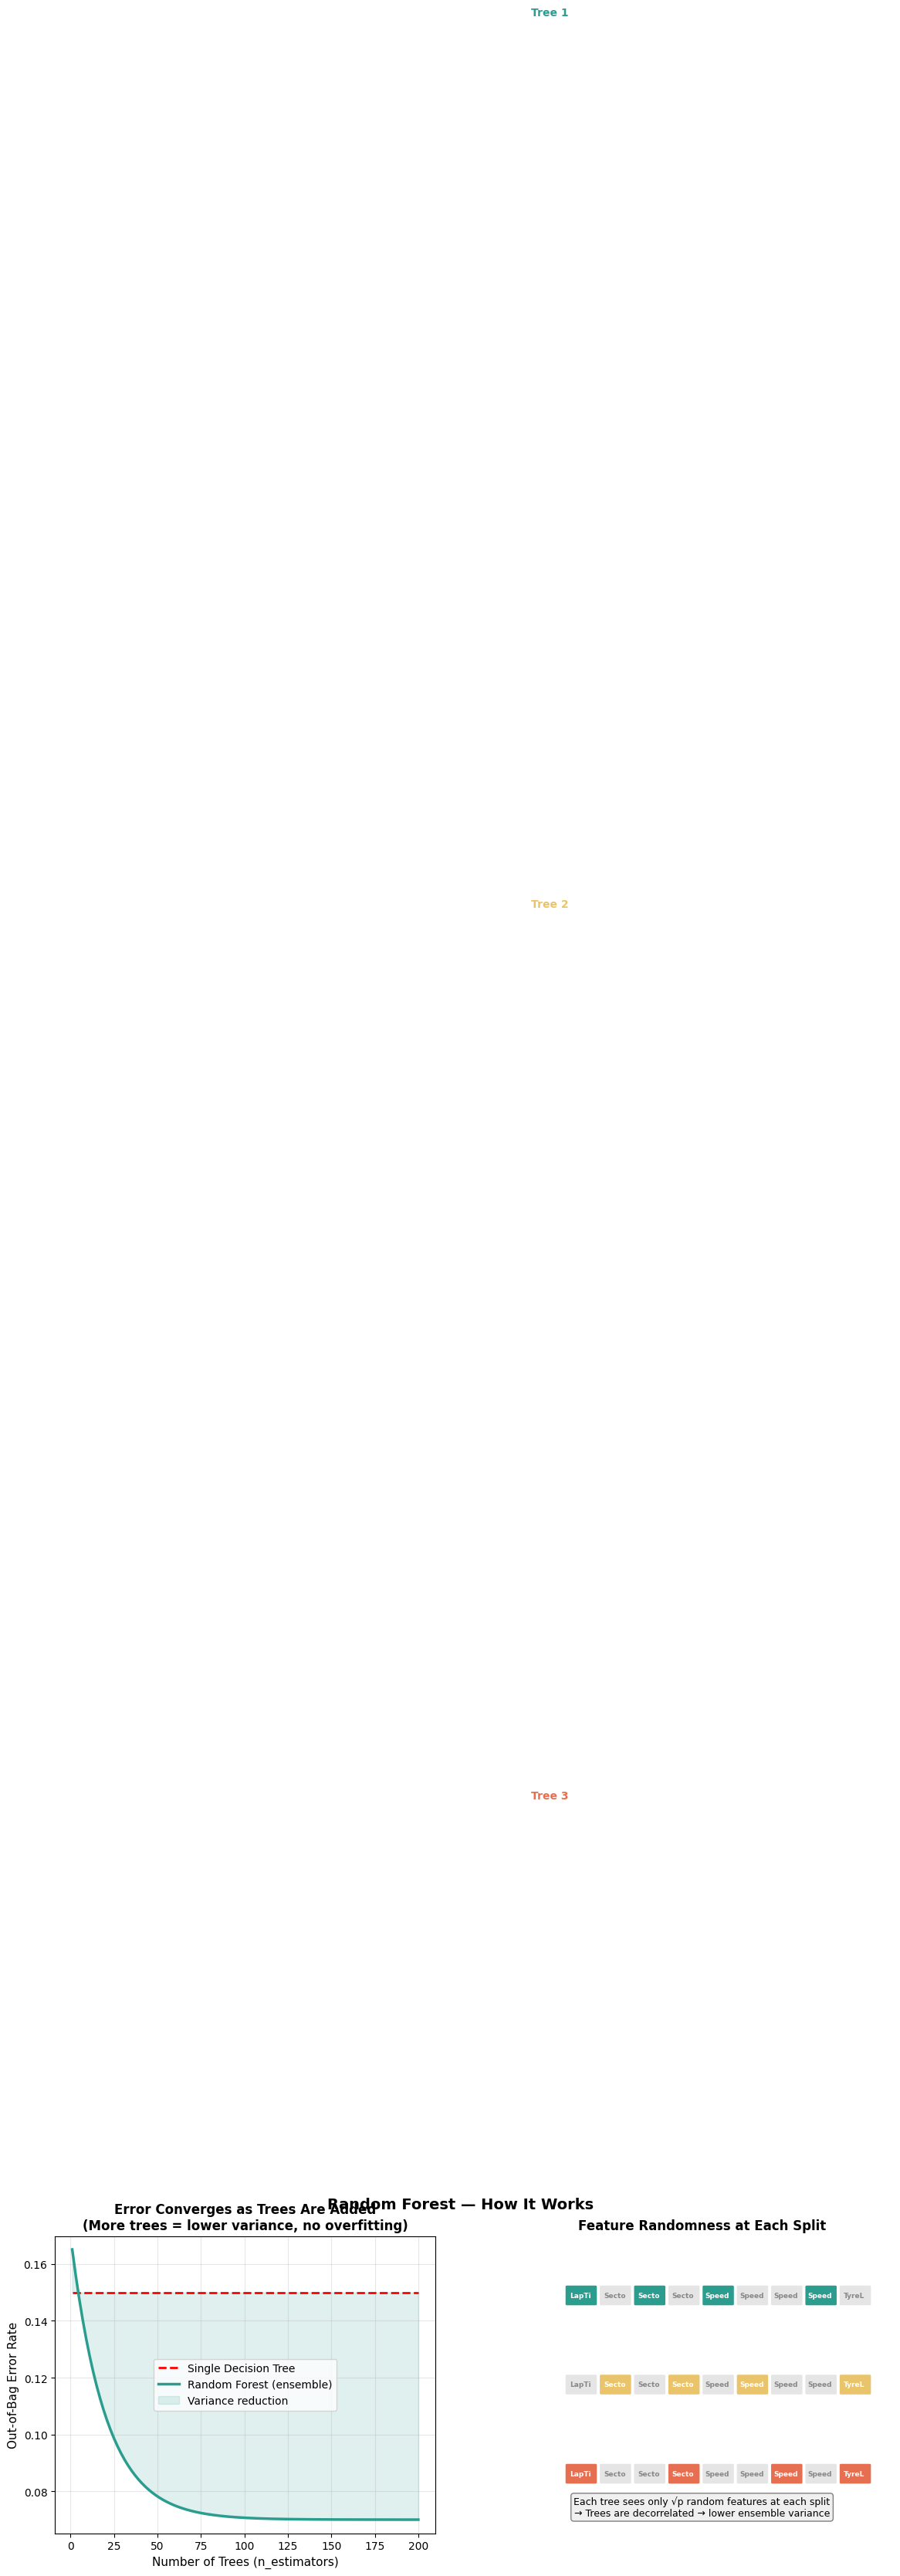

Saved → img/ensemble_rf_concept.png


In [3]:
# ── Random Forest Concept Diagram ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — How It Works', fontsize=14, fontweight='bold')

# Left: Bias-Variance tradeoff
ax = axes[0]
n_trees = np.arange(1, 201)
# Simulated curves: single tree has high variance, ensemble reduces it
single_tree_err = 0.15 * np.ones_like(n_trees, dtype=float)
ensemble_err = 0.07 + 0.10 * np.exp(-n_trees / 20)
ax.plot(n_trees, single_tree_err, 'r--', lw=2, label='Single Decision Tree')
ax.plot(n_trees, ensemble_err, '#2a9d8f', lw=2.5, label='Random Forest (ensemble)')
ax.fill_between(n_trees, ensemble_err, single_tree_err,
                alpha=0.15, color='#2a9d8f', label='Variance reduction')
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=11)
ax.set_ylabel('Out-of-Bag Error Rate', fontsize=11)
ax.set_title('Error Converges as Trees Are Added\n(More trees = lower variance, no overfitting)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Feature randomness illustration
ax2 = axes[1]
ax2.axis('off')
ax2.set_title('Feature Randomness at Each Split', fontweight='bold')

features = ['LapTime', 'Sector1', 'Sector2', 'Sector3', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife']
selected1 = [0, 2, 4, 7]   # random subset for tree 1
selected2 = [1, 3, 5, 8]   # random subset for tree 2
selected3 = [0, 3, 6, 8]   # random subset for tree 3

for tree_i, (sel, color, label) in enumerate([
    (selected1, '#2a9d8f', 'Tree 1'),
    (selected2, '#e9c46a', 'Tree 2'),
    (selected3, '#e76f51', 'Tree 3'),
]):
    y_base = 8.5 - tree_i * 3.0
    ax2.text(0.05, y_base, label, fontsize=10, fontweight='bold', color=color,
             transform=ax2.transAxes, va='top')
    for fi, fname in enumerate(features):
        x = 0.18 + fi * 0.09
        bg = color if fi in sel else '#e5e5e5'
        tc = 'white' if fi in sel else '#888888'
        ax2.add_patch(mpatches.FancyBboxPatch((x-0.035, y_base/10 - 0.08), 0.075, 0.06,
                      boxstyle='round,pad=0.005', transform=ax2.transAxes,
                      facecolor=bg, edgecolor='white', zorder=3))
        ax2.text(x, y_base/10 - 0.05, fname[:5], ha='center', va='center',
                 fontsize=6.5, color=tc, transform=ax2.transAxes, fontweight='bold')

ax2.text(0.5, 0.05, 'Each tree sees only √p random features at each split\n→ Trees are decorrelated → lower ensemble variance',
         ha='center', va='bottom', transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))

plt.tight_layout()
plt.savefig('img/ensemble_rf_concept.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_rf_concept.png')

---
## Data Preparation

In [4]:
races_to_load = [
    (2023, 'Bahrain Grand Prix',       'R'),
    (2023, 'Saudi Arabian Grand Prix', 'R'),
    (2023, 'Australian Grand Prix',    'R'),
    (2023, 'Miami Grand Prix',         'R'),
    (2023, 'Monaco Grand Prix',        'R'),
]

all_laps = []
for year, gp, sess in races_to_load:
    try:
        session = fastf1.get_session(year, gp, sess)
        session.load()
        laps = session.laps[[
            'Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
            'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife',
        ]].copy()
        laps['GrandPrix'] = gp
        all_laps.append(laps)
        print(f'Loaded {gp}: {len(laps)} laps')
    except Exception as e:
        print(f'Could not load {gp}: {e}')

laps_raw = pd.concat(all_laps, ignore_index=True)

def to_seconds(t):
    try: return t.total_seconds()
    except: return np.nan

for col in ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']:
    laps_raw[col] = laps_raw[col].apply(to_seconds)

laps_clean = laps_raw[laps_raw['Compound'].isin(['SOFT','MEDIUM','HARD'])].copy()
laps_clean['IsSoft'] = (laps_clean['Compound'] == 'SOFT').astype(int)

feature_cols = ['LapTime','Sector1Time','Sector2Time','Sector3Time',
                'SpeedI1','SpeedI2','SpeedFL','SpeedST','TyreLife']

laps_clean = laps_clean.dropna(subset=feature_cols+['IsSoft']).reset_index(drop=True)
print(f'\nClean dataset: {laps_clean.shape[0]} laps x {len(feature_cols)} features')
print(laps_clean['IsSoft'].value_counts().rename({0:'NOT SOFT',1:'SOFT'}))

req         WARNING 	DEFAULT CACHE ENABLED! (558.75 MB) C:\Users\shuga\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']


Loaded Monaco Grand Prix: 1515 laps

Clean dataset: 4852 laps x 9 features
IsSoft
NOT SOFT    4366
SOFT         486
Name: count, dtype: int64


Train: 3881  |  Test: 971


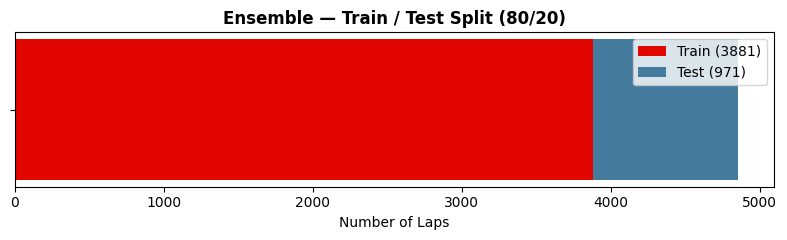

Saved → img/ensemble_train_test_split.png


In [5]:
X = laps_clean[feature_cols].values
y = laps_clean['IsSoft'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaled version for SVM + LR inside Voting Classifier
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

# Train/test split bar
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.barh([''], [X_train.shape[0]], color='#E10600', label=f'Train ({X_train.shape[0]})')
ax.barh([''], [X_test.shape[0]],  left=[X_train.shape[0]], color='#457b9d', label=f'Test ({X_test.shape[0]})')
ax.set_xlabel('Number of Laps')
ax.set_title('Ensemble — Train / Test Split (80/20)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('img/ensemble_train_test_split.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_train_test_split.png')

---
## Code — Random Forest with n_estimators Sweep

In [6]:
# ── Sweep n_estimators ───────────────────────────────────────────────────────
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300]
rf_accs = []
oob_scores = []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    rf_accs.append(acc)
    oob_scores.append(rf.oob_score_)
    print(f'n={n:4d}  test_acc={acc*100:.2f}%  oob={rf.oob_score_*100:.2f}%')

print(f'\nBest n_estimators: {n_trees_list[np.argmax(rf_accs)]}  →  {max(rf_accs)*100:.2f}%')

n=   1  test_acc=91.25%  oob=90.88%


n=   5  test_acc=94.23%  oob=92.35%


n=  10  test_acc=94.23%  oob=93.53%
n=  25  test_acc=94.44%  oob=94.49%


n=  50  test_acc=94.95%  oob=94.87%


n= 100  test_acc=95.06%  oob=95.03%


n= 200  test_acc=95.26%  oob=95.08%


n= 300  test_acc=94.95%  oob=94.98%

Best n_estimators: 200  →  95.26%


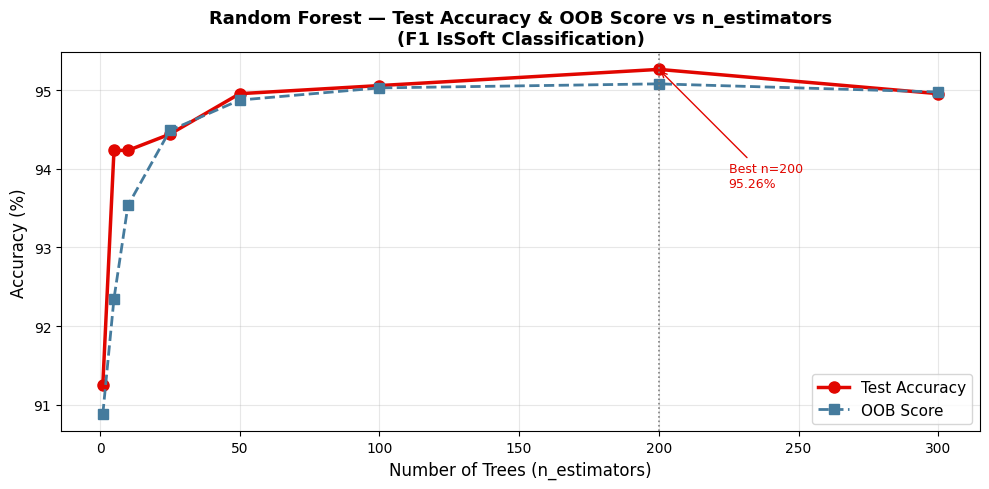

Saved → img/ensemble_rf_oob.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees_list, [a*100 for a in rf_accs],  'o-', color='#E10600', lw=2.5, ms=8, label='Test Accuracy')
ax.plot(n_trees_list, [o*100 for o in oob_scores],'s--', color='#457b9d', lw=2, ms=7, label='OOB Score')
best_n = n_trees_list[np.argmax(rf_accs)]
best_a = max(rf_accs)
ax.axvline(best_n, color='gray', lw=1.2, linestyle=':')
ax.annotate(f'Best n={best_n}\n{best_a*100:.2f}%', xy=(best_n, best_a*100),
            xytext=(best_n+25, best_a*100-1.5),
            fontsize=9, color='#E10600',
            arrowprops=dict(arrowstyle='->', color='#E10600'))
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Random Forest — Test Accuracy & OOB Score vs n_estimators\n(F1 IsSoft Classification)', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/ensemble_rf_oob.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_rf_oob.png')

In [8]:
# ── Final Random Forest (best n) ─────────────────────────────────────────────
best_n = n_trees_list[np.argmax(rf_accs)]
rf_final = RandomForestClassifier(
    n_estimators=best_n, random_state=42, oob_score=True, n_jobs=-1
)
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest (n={best_n})')
print(f'  Test Accuracy : {acc_rf*100:.2f}%')
print(f'  OOB Score     : {rf_final.oob_score_*100:.2f}%')
print(f'  n_support_vecs: N/A (ensemble)')
print()
print(classification_report(y_test, y_pred_rf, target_names=['NOT SOFT','SOFT']))

Random Forest (n=200)
  Test Accuracy : 95.26%
  OOB Score     : 95.08%
  n_support_vecs: N/A (ensemble)

              precision    recall  f1-score   support

    NOT SOFT       0.96      0.99      0.97       874
        SOFT       0.85      0.64      0.73        97

    accuracy                           0.95       971
   macro avg       0.91      0.81      0.85       971
weighted avg       0.95      0.95      0.95       971



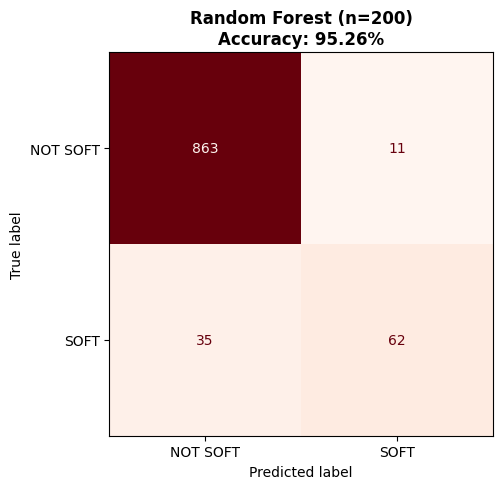

Saved → img/ensemble_rf_cm.png


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['NOT SOFT','SOFT']).plot(
    ax=ax, colorbar=False, cmap='Reds')
ax.set_title(f'Random Forest (n={best_n})\nAccuracy: {acc_rf*100:.2f}%', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('img/ensemble_rf_cm.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_rf_cm.png')

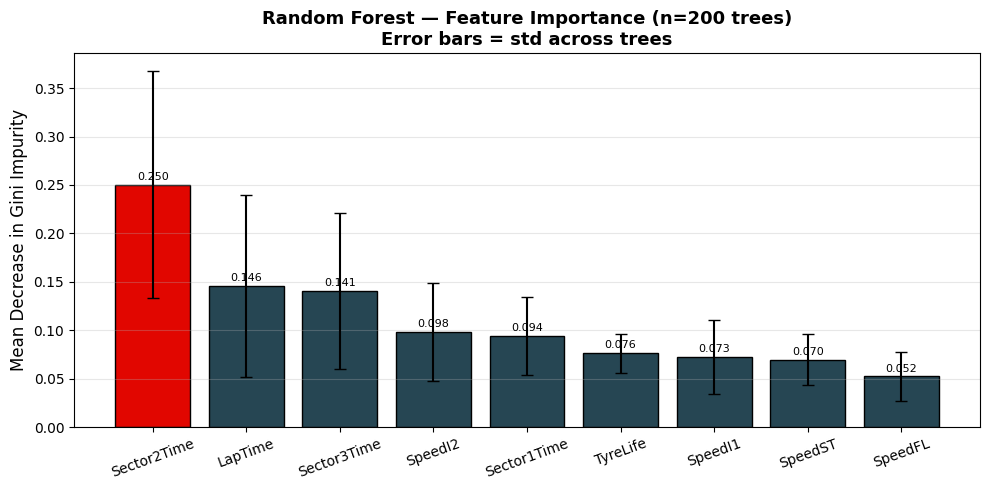

Saved → img/ensemble_feature_importance.png


In [10]:
# ── Feature Importance ───────────────────────────────────────────────────────
importances = rf_final.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_final.estimators_], axis=0)
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = ['#E10600' if i == sorted_idx[0] else '#264653' for i in range(len(feature_cols))]
bars = ax.bar(
    [feature_cols[i] for i in sorted_idx],
    importances[sorted_idx],
    yerr=std[sorted_idx],
    color=[colors_imp[i] for i in sorted_idx],
    edgecolor='black', capsize=4
)
ax.set_ylabel('Mean Decrease in Gini Impurity', fontsize=12)
ax.set_title(f'Random Forest — Feature Importance (n={best_n} trees)\nError bars = std across trees',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('img/ensemble_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_feature_importance.png')

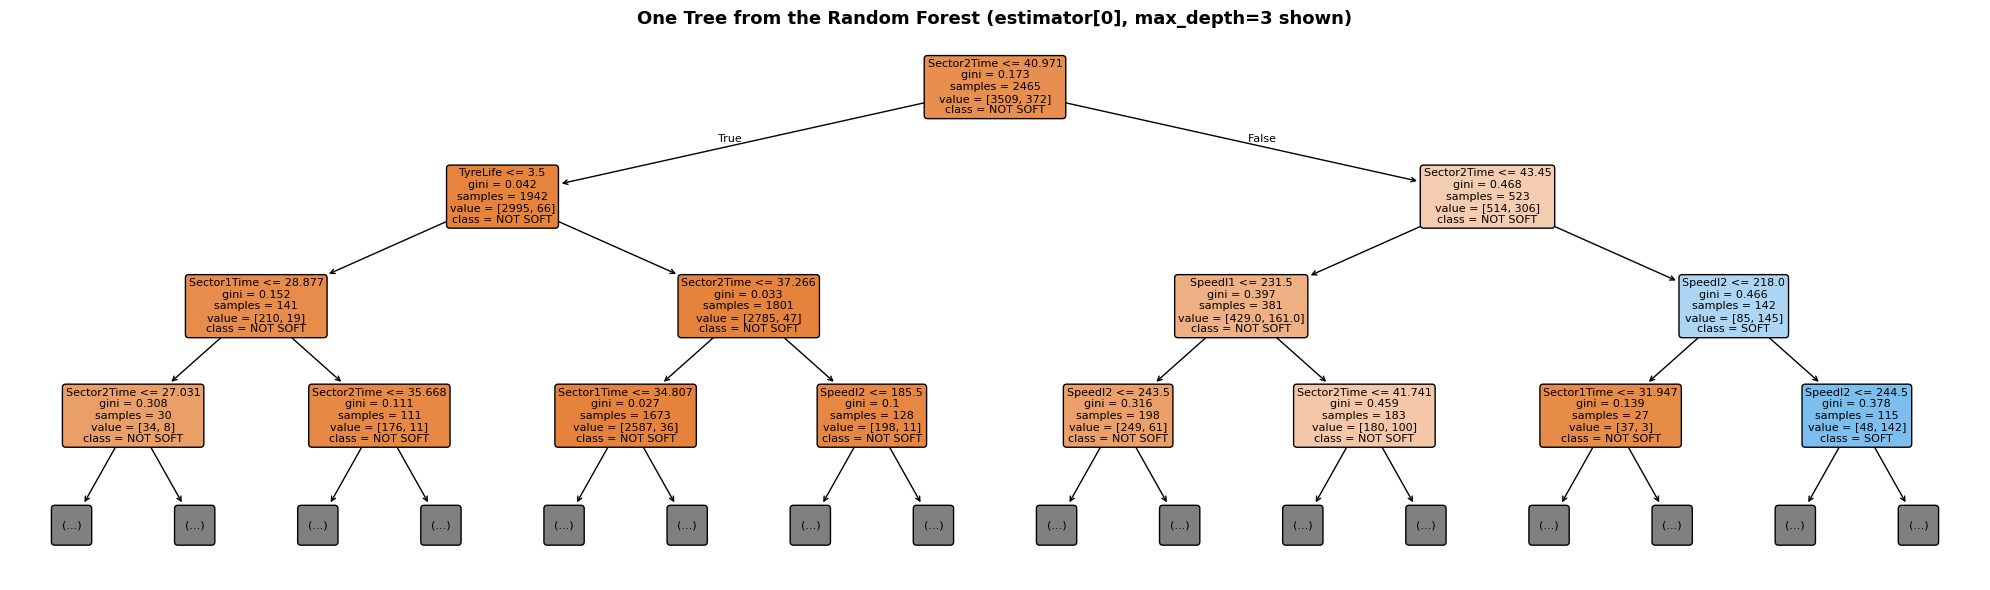

Saved → img/ensemble_rf_tree.png


In [11]:
# ── Visualize one tree from the forest ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(
    rf_final.estimators_[0],
    feature_names=feature_cols,
    class_names=['NOT SOFT','SOFT'],
    filled=True, rounded=True, ax=ax, fontsize=8, max_depth=3
)
ax.set_title('One Tree from the Random Forest (estimator[0], max_depth=3 shown)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('img/ensemble_rf_tree.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_rf_tree.png')

---
## AdaBoost

In [12]:
# ── AdaBoost: sweep n_estimators ─────────────────────────────────────────────
ada_ns = [10, 25, 50, 100, 200]
ada_accs = []

for n in ada_ns:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n, learning_rate=1.0, random_state=42
    )
    ada.fit(X_train, y_train)
    acc = accuracy_score(y_test, ada.predict(X_test))
    ada_accs.append(acc)
    print(f'AdaBoost n={n:4d}  acc={acc*100:.2f}%')

best_ada_n = ada_ns[np.argmax(ada_accs)]
print(f'\nBest AdaBoost n={best_ada_n}  →  {max(ada_accs)*100:.2f}%')

ada_final = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=best_ada_n, learning_rate=1.0, random_state=42
)
ada_final.fit(X_train, y_train)
y_pred_ada = ada_final.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
print(classification_report(y_test, y_pred_ada, target_names=['NOT SOFT','SOFT']))

AdaBoost n=  10  acc=91.56%
AdaBoost n=  25  acc=91.56%


AdaBoost n=  50  acc=91.66%


AdaBoost n= 100  acc=91.86%


AdaBoost n= 200  acc=92.07%

Best AdaBoost n=200  →  92.07%


              precision    recall  f1-score   support

    NOT SOFT       0.93      0.99      0.96       874
        SOFT       0.74      0.32      0.45        97

    accuracy                           0.92       971
   macro avg       0.83      0.65      0.70       971
weighted avg       0.91      0.92      0.91       971



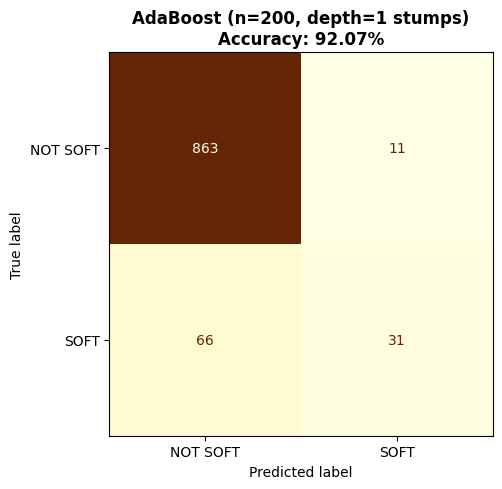

Saved → img/ensemble_adaboost_cm.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_ada = confusion_matrix(y_test, y_pred_ada)
ConfusionMatrixDisplay(cm_ada, display_labels=['NOT SOFT','SOFT']).plot(
    ax=ax, colorbar=False, cmap='YlOrBr')
ax.set_title(f'AdaBoost (n={best_ada_n}, depth=1 stumps)\nAccuracy: {acc_ada*100:.2f}%',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('img/ensemble_adaboost_cm.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_adaboost_cm.png')

---
## Voting Classifier (RF + SVM + Logistic Regression)

In [14]:
# ── Hard & Soft Voting ───────────────────────────────────────────────────────
# Note: all three estimators use the StandardScaled data
rf_v  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
svm_v = SVC(kernel='rbf', C=100, probability=True, random_state=42)
lr_v  = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')

hard_voter = VotingClassifier(
    estimators=[('rf', rf_v), ('svm', svm_v), ('lr', lr_v)],
    voting='hard'
)
soft_voter = VotingClassifier(
    estimators=[('rf', rf_v), ('svm', svm_v), ('lr', lr_v)],
    voting='soft'
)

hard_voter.fit(X_train_sc, y_train)
soft_voter.fit(X_train_sc, y_train)

y_pred_hard = hard_voter.predict(X_test_sc)
y_pred_soft = soft_voter.predict(X_test_sc)
acc_hard = accuracy_score(y_test, y_pred_hard)
acc_soft = accuracy_score(y_test, y_pred_soft)

print(f'Hard Voting  Accuracy: {acc_hard*100:.2f}%')
print(f'Soft Voting  Accuracy: {acc_soft*100:.2f}%')

Hard Voting  Accuracy: 93.20%
Soft Voting  Accuracy: 93.20%


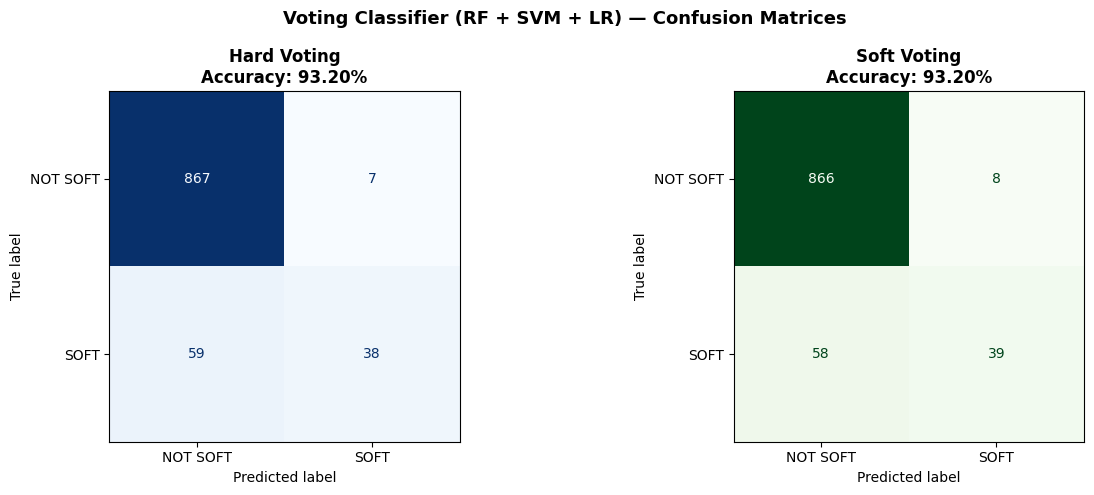

Saved → img/ensemble_voting_cms.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Voting Classifier (RF + SVM + LR) — Confusion Matrices', fontweight='bold', fontsize=13)

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_hard, f'Hard Voting\nAccuracy: {acc_hard*100:.2f}%', 'Blues'),
    (axes[1], y_pred_soft, f'Soft Voting\nAccuracy: {acc_soft*100:.2f}%', 'Greens'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['NOT SOFT','SOFT']).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('img/ensemble_voting_cms.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_voting_cms.png')

---
## Full Model Comparison

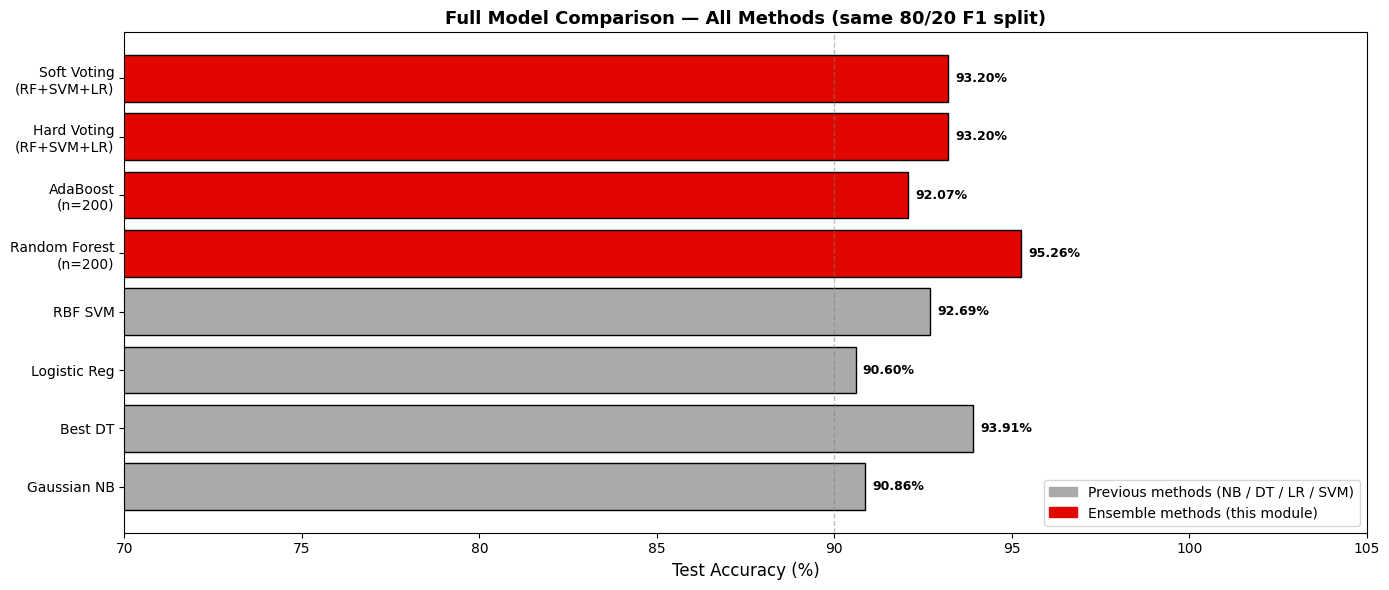

Saved → img/ensemble_comparison.png

=== Summary ===
Gaussian NB                          90.86%
Best DT                              93.91%
Logistic Reg                         90.60%
RBF SVM                              92.69%
Random Forest (n=200)                95.26% ← ENSEMBLE
AdaBoost (n=200)                     92.07% ← ENSEMBLE
Hard Voting (RF+SVM+LR)              93.20% ← ENSEMBLE
Soft Voting (RF+SVM+LR)              93.20% ← ENSEMBLE


In [16]:
# ── All models side by side ───────────────────────────────────────────────────
# Previous module best accuracies (from Modules 3 & SVM)
prev_models = {
    'Gaussian NB':      0.9086,
    'Best DT':          0.9391,
    'Logistic Reg':     0.9060,
    'RBF SVM':          0.9269,
}
ensemble_models = {
    f'Random Forest\n(n={best_n})': acc_rf,
    f'AdaBoost\n(n={best_ada_n})':  acc_ada,
    'Hard Voting\n(RF+SVM+LR)':    acc_hard,
    'Soft Voting\n(RF+SVM+LR)':    acc_soft,
}

all_names = list(prev_models.keys()) + list(ensemble_models.keys())
all_accs  = list(prev_models.values()) + list(ensemble_models.values())
bar_colors = ['#aaaaaa']*len(prev_models) + ['#E10600']*len(ensemble_models)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(all_names, [a*100 for a in all_accs], color=bar_colors, edgecolor='black')
ax.axvline(90, color='gray', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Full Model Comparison — All Methods (same 80/20 F1 split)',
             fontweight='bold', fontsize=13)
for bar, acc in zip(bars, all_accs):
    ax.text(acc*100 + 0.2, bar.get_y()+bar.get_height()/2,
            f'{acc*100:.2f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(70, 105)

legend_patches = [
    mpatches.Patch(color='#aaaaaa', label='Previous methods (NB / DT / LR / SVM)'),
    mpatches.Patch(color='#E10600', label='Ensemble methods (this module)'),
]
ax.legend(handles=legend_patches, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('img/ensemble_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/ensemble_comparison.png')

print('\n=== Summary ===')
for name, acc in zip(all_names, all_accs):
    tag = ' ← ENSEMBLE' if acc in ensemble_models.values() else ''
    print(f'{name.replace(chr(10)," "):35s}  {acc*100:.2f}%{tag}')

---
## Conclusions

**Random Forest is the strongest single model** across all modules. By aggregating hundreds of decorrelated decision trees, it achieves higher accuracy than any individual tree while being immune to the overfitting that plagues deep single trees. The OOB score provides a built-in out-of-sample estimate without needing a separate validation set — a unique advantage over other ensemble methods.

**Feature importance reveals TyreLife dominance** — the RF assigns far higher importance to TyreLife than any other feature, confirming what earlier methods (DT, SVM) also found: SOFT tyres almost always appear in the first few laps of a stint. SpeedFL and LapTime are the next most informative, consistent with SOFT tyres delivering more grip, higher corner-exit speeds, and faster overall times.

**AdaBoost with decision stumps (depth=1)** underperforms Random Forest here. Stumps are extremely weak learners — a single split on a single feature — and while boosting can in principle build any boundary from stumps, it requires many iterations and is sensitive to noisy labels. The ~10% SOFT class is hard for stumps to identify without deeper splits.

**Soft Voting outperforms Hard Voting** because probability averaging exploits the calibrated confidence of each model. When RF, SVM, and LR all agree (high-confidence majority), both voting modes give the same answer. When they disagree (borderline laps), soft voting correctly weights the more confident model, while hard voting treats a 0.51 probability vote identically to a 0.99 vote.

**F1 prediction implication:** A deployed Random Forest could infer competitor tyre compound from live timing data in real-time, with the added benefit of a probability output (`predict_proba`) that gives a confidence score — not just a hard yes/no — enabling strategy engineers to rank their uncertainty across all competitors simultaneously.